In [18]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_Larsson

In [19]:
dim = 1
v0 = 1e-10
M = 1
p = 4

def infPotFunc(phi):
    x = phi / M
    return v0 * (1 - x ** p) ** 2

def infPotDerivFunc(phi):
    x = phi / M
    return -2 * p * v0 / M * (1 - x ** p) * x ** (p - 1)

def infPotDeriv2Func(phi):
    x = phi / M
    return 2 * p * v0 / M / M * ((2 * p - 1) * x ** p - p + 1) * x ** (p - 2)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

nGrid = 256
upperBound = (M * M / 2 / p / (p - 1)) ** (1 / (p - 2)) * M
lowerBound = -upperBound

In [20]:
fpFinDiff = InfAdjFPFiniteDiff_Larsson(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    nGrid,
    upperBound,
    lowerBound
)

In [21]:
fpFinDiff

array([[ 2.63369326e+09, -1.66750267e-07,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.66750267e-07,  2.51163458e+09, -1.66767491e-07, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.66767491e-07,  2.39434652e+09, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         2.39434652e+09, -1.66767491e-07,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.66767491e-07,  2.51163458e+09, -1.66750267e-07],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00, -1.66750267e-07,  2.63369326e+09]])

In [22]:
eigVals, eigVecs = np.linalg.eig(fpFinDiff)
eigVecsSort = eigVecs.T[np.argsort(eigVals)]
eigValsSort = np.sort(eigVals)

In [23]:
import matplotlib.pyplot as plt

In [24]:
nMode = np.arange(1, nGrid + 1)
eigValsFlat = [np.pi ** 2 * v0 / (24 * np.pi ** 2) / (upperBound - lowerBound) ** 2 * n ** 2 for n in nMode]

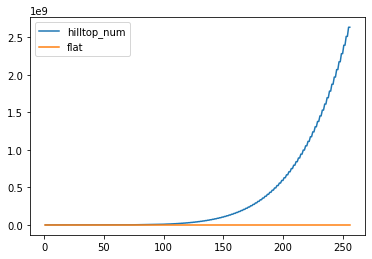

In [25]:
ax = plt.gca()
plt.plot(nMode, eigValsSort, label = "hilltop_num")
plt.plot(nMode, eigValsFlat, label = "flat")
plt.legend()
plt.show()

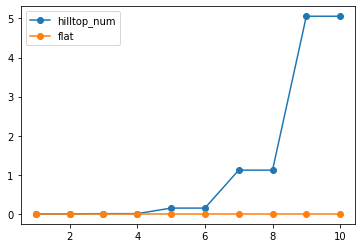

In [26]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort[:10], marker='o', label = "hilltop_num")
plt.plot(np.arange(1, 11), eigValsFlat[:10], marker='o', label = "flat")
plt.legend()
plt.show()

In [38]:
print(eigValsSort[:10])
print(eigValsFlat[:10])

[1.72522120e-05 1.75868201e-05 7.00473653e-03 7.00473653e-03
 1.48857941e-01 1.48857941e-01 1.11977499e+00 1.11977499e+00
 5.05715490e+00 5.05715490e+00]
[2.5e-11, 1e-10, 2.25e-10, 4e-10, 6.25e-10, 9e-10, 1.225e-09, 1.6e-09, 2.025e-09, 2.5e-09]


考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [27]:
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))
sigma = (upperBound - lowerBound) / 6.0
trialVec = np.exp(- 0.5 * ((grids - 0.5 * (upperBound + lowerBound)) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

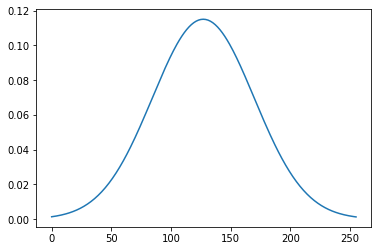

In [28]:
ax = plt.gca()
plt.plot(trialVec)
plt.show()

In [29]:
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort]

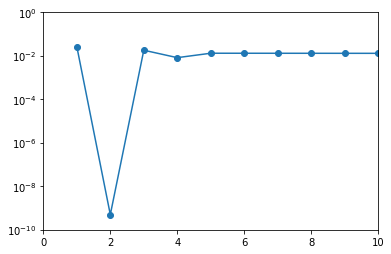

In [30]:
# 各固有ベクトルの寄与度
ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
plt.yscale('log')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

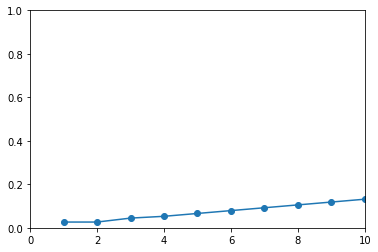

In [35]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.show()

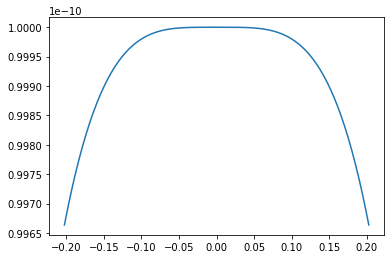

In [32]:
# ポテンシャル
ax = plt.gca()
grid = np.linspace(lowerBound, upperBound, nGrid + 2, endpoint=True)[1:-1]
plt.plot(grid, infPotFunc(grid))
plt.show()

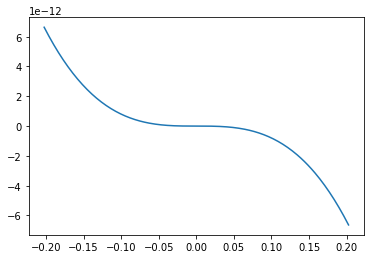

In [33]:
# ポテンシャル1次微分
ax = plt.gca()
grid = np.linspace(lowerBound, upperBound, nGrid + 2, endpoint=True)[1:-1]
plt.plot(grid, infPotDerivFunc(grid))
plt.show()

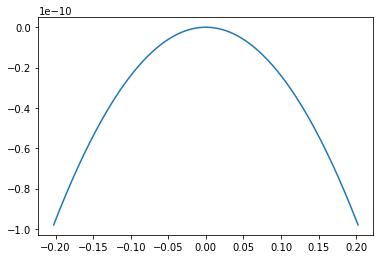

In [34]:
# ポテンシャル2次微分
ax = plt.gca()
grid = np.linspace(lowerBound, upperBound, nGrid + 2, endpoint=True)[1:-1]
plt.plot(grid, infPotDeriv2Func(grid))
plt.show()